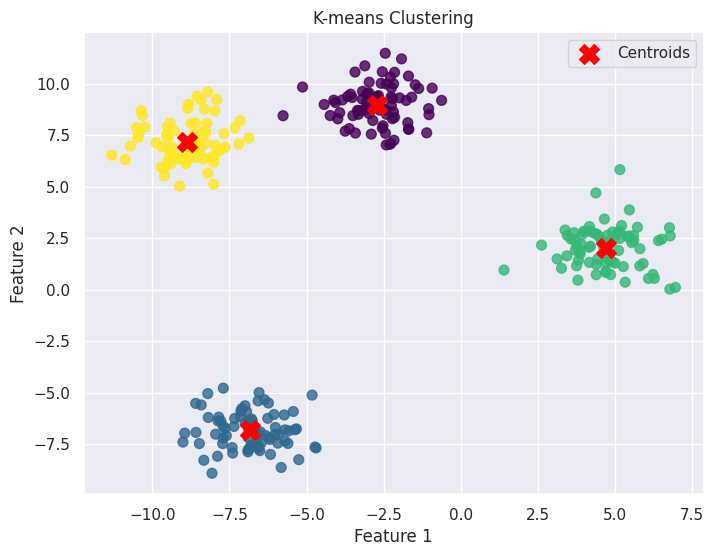

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import seaborn as sns
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, random_state=42) # Corrected 'randon_state' to 'random_state' and removed unnecessary comma after X, used _ for unused return value
model = KMeans(n_clusters=4, n_init='auto', random_state=42) # Corrected 'Model' to 'model', added n_init and random_state for reproducibility
model.fit(X)

sns.set(style="darkgrid")
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=model.labels_, cmap='viridis', s=50, alpha=0.8) # Completed the plt.scatter call with data, colors, size, and transparency
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], marker='X', s=200, color='red', label='Centroids') # Plotting centroids
plt.title('K-means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

Generated DataFrame:
    Ingresos  Gastos
0       2536    6135
1       9323    4271
2       8044    1037
3       6721    7321
4       5638     749
5       3002    4127
6       7639    5561
7       3119    3150
8       8302    2932
9       6161    1939
10      4398    4544
11      5548    2769

--- Inertia Calculation ---
Inertia for Cluster 0 (Centroid 0): 6575927.75
Inertia for Cluster 1 (Centroid 1): 6541914.75
Inertia for Cluster 2 (Centroid 2): 14115659.50
Total Inertia of the model: 27233502.00


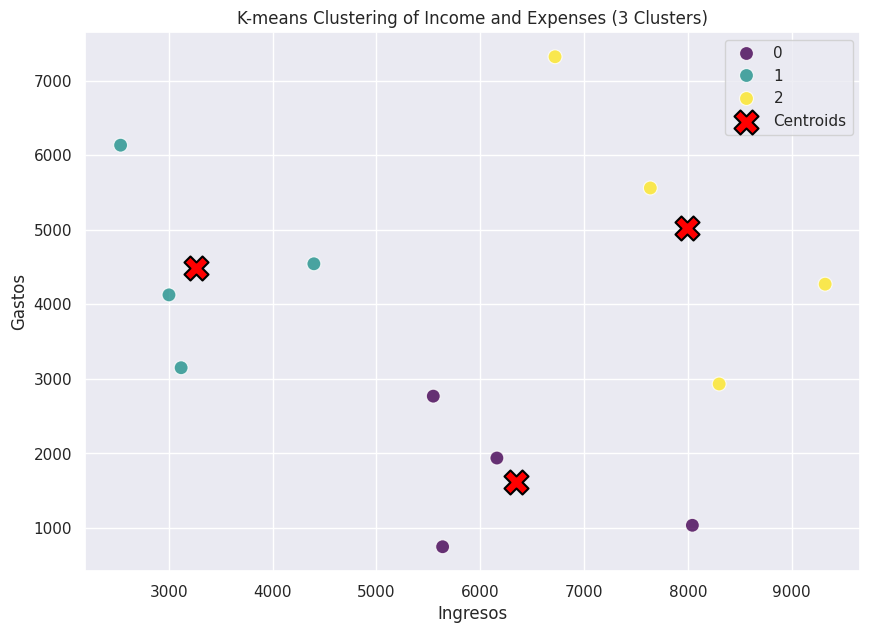

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate DataFrame with 12 records of income and expenses
data = {
    'Ingresos': np.random.randint(1000, 10000, 12),
    'Gastos': np.random.randint(500, 8000, 12)
}
df = pd.DataFrame(data)

print("Generated DataFrame:")
print(df)

# 2. Apply K-means with 3 clusters
model_3_clusters = KMeans(n_clusters=3, random_state=42, n_init='auto')
model_3_clusters.fit(df[['Ingresos', 'Gastos']])

df['Cluster'] = model_3_clusters.labels_

# Calculate and print inertia per centroid and total inertia
print("\n--- Inertia Calculation ---")
centroids = model_3_clusters.cluster_centers_
for i in range(model_3_clusters.n_clusters):
    cluster_points = df[df['Cluster'] == i][['Ingresos', 'Gastos']].values
    centroid = centroids[i]
    # Calculate sum of squared distances for points in this cluster to its centroid
    inertia_cluster = np.sum((cluster_points - centroid)**2)
    print(f"Inertia for Cluster {i} (Centroid {i}): {inertia_cluster:.2f}")

total_inertia = model_3_clusters.inertia_
print(f"Total Inertia of the model: {total_inertia:.2f}")

# 3. Visualize the results
sns.set(style="darkgrid")
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Ingresos',
    y='Gastos',
    hue='Cluster',
    palette='viridis',
    s=100, # size of points
    alpha=0.8, # transparency
    legend='full'
)

# Plotting centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=300, # size of centroid markers
    color='red',
    label='Centroids',
    edgecolors='black',
    linewidths=1.5
)

plt.title('K-means Clustering of Income and Expenses (3 Clusters)')
plt.xlabel('Ingresos')
plt.ylabel('Gastos')
plt.legend()
plt.grid(True)
plt.show()